# Data Preprocessing — Concepts & Explanation

---

## 1. Calculate Return Values

Use **log returns** instead of simple percentage returns.

**Simple return:**

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} \times 100$$

**Log return (what we use):**

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) \times 100$$

> Multiply by 100 to express it as a percentage.

---


**Example:**
- Price goes \$100 → \$110 → \$100
- Simple return: +10% then -9.09% ≠ 0 (not symmetric)
- Log return: +9.53% then -9.53% = 0

---

### Code Example

```python
import numpy as np

# Log return calculation
df['SP500_Return'] = np.log(df['SP500_Close'] / df['SP500_Close'].shift(1)) * 100

# shift(1) means "last month closing price"
# So we are computing: ln(last month close / monthly close) * 100
```

---

### Sectors We Calculate Returns For

| Column Name | Sector |
|---|---|
| `SP500_Return` | Overall S&P 500 |
| `Tech_Return` | Information Technology |
| `Healthcare_Return` | Healthcare |
| `Finance_Return` | Financials |
| `Industrial_Return` | Industrials |
| `Energy_Return` | Energy |

---
---

## 2. Transform Input (Macro) Variables

Raw macro variables like CPI, Interest Rate, and GDP are **not stationary** — they trend upward or downward over time. If we feed them directly into a model, the model gets confused by the trend rather than learning the true relationship.

**Example:**  
CPI in 2000 = 175, CPI in 2020 = 260. The model might just learn "time passes → CPI goes up" which is useless for prediction.

---

### Solution — Transform Each Variable

We apply different transformations depending on the variable type:

---

#### A) First Difference — for slow-moving economic variables

**Formula:**

$$\Delta X_t = X_t - X_{t-1}$$

This removes the trend by focusing on **change from last month** instead of the raw level.

**Applied to:**
- `CPI` → `CPI_Change` (change in inflation)
- `Interest_Rate` → `Rate_Change` (change in rate)
- `Unemployment` → `Unemp_Change` (change in unemployment)
- `USD_Index` → `USD_Change` (change in dollar strength)
- `VIX` → `VIX_Change` (change in market fear)

```python
df['CPI_Change']  = df['CPI'].diff()           # CPI this month - last month
df['Rate_Change'] = df['Interest_Rate'].diff()  # Rate this month - last month
df['Unemp_Change']= df['Unemployment'].diff()
df['USD_Change']  = df['USD_Index'].diff()
df['VIX_Change']  = df['VIX'].diff()
```

---

#### B) Year-over-Year Growth — for GDP

GDP is reported **quarterly** (every 3 months), not monthly. We:
1. First **interpolate** to fill in missing monthly values
2. Then calculate **year-over-year (YoY) growth** to capture economic cycles properly

**Formula:**

$$\text{GDP\_Growth}_t = \left(\frac{\text{GDP}_t}{\text{GDP}_{t-12}} - 1\right) \times 100$$

> Comparing to the same month last year removes seasonal patterns.

```python
# Step 1: fill quarterly gaps with smooth interpolation
df['GDP'] = df['GDP'].interpolate(method='cubic')

# Step 2: year-over-year growth %
df['GDP_Growth'] = ((df['GDP'] / df['GDP'].shift(12)) - 1) * 100
```

---

#### C) Levels (no transformation) — for Credit Spread

Credit Spread = BAA bond yield − AAA bond yield

This variable **naturally fluctuates around a stable mean** (already stationary), so no transformation is needed.

```python
df['Credit_Spread'] = df['BAA'] - df['AAA']   # use directly as-is
```

---

### Summary Table

| Raw Variable | Transformed Variable | Method | Why |
|---|---|---|---|
| `CPI` | `CPI_Change` | First difference | Removes upward trend |
| `Interest_Rate` | `Rate_Change` | First difference | Removes trend |
| `Unemployment` | `Unemp_Change` | First difference | Removes trend |
| `USD_Index` | `USD_Change` | First difference | Removes trend |
| `VIX` | `VIX_Change` | First difference | Removes trend |
| `GDP` | `GDP_Growth` | YoY % growth | Removes seasonality + trend |
| `Credit_Spread` | `Credit_Spread` | None (levels) | Already stationary |

---

### Final Features Used in the Model

After transformation, these 7 variables are used as model inputs:

```python
feature_cols = [
    'CPI_Change',     # monthly change in inflation
    'Rate_Change',    # monthly change in interest rate
    'GDP_Growth',     # year-over-year GDP growth %
    'Unemp_Change',   # monthly change in unemployment
    'USD_Change',     # monthly change in dollar index
    'VIX_Change',     # monthly change in market volatility
    'Credit_Spread'   # difference between BAA and AAA bond yields
]
```

In [5]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))
print(f"Project root: {project_root}")


from src.data_preprocessing import preprocess_pipeline
from utils.savePlots import save

PATH = "../data/processed/main_data.csv"
PLT_SAVE_DIR = "eda_after_preprocessing"

# check if path is correct and file can be read
df_raw = pd.read_csv(PATH)
df_raw.info()





Project root: /Users/macbook/Desktop/macroeconomic-impact-stock-ml
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      312 non-null    object 
 1   CPI                       311 non-null    float64
 2   Interest_Rate             312 non-null    float64
 3   GDP                       104 non-null    float64
 4   Unemployment              311 non-null    float64
 5   VIX                       312 non-null    float64
 6   BAA                       312 non-null    float64
 7   AAA                       312 non-null    float64
 8   Credit_Spread             312 non-null    float64
 9   SP500_Energy_Open         312 non-null    float64
 10  SP500_Energy_Close        312 non-null    float64
 11  SP500_Energy_Volume       312 non-null    int64  
 12  SP500_Healthcare_Open     312 non-null    float64
 13

In [6]:
# run the preprocessing pipeline and get the results

result = preprocess_pipeline(PATH)
df, X_train, X_val, X_test, y_train, y_val, y_test, train_dates, val_dates, test_dates = result


PREPROCESSING PIPELINE

Loaded 312 rows from ../data/processed/main_data.csv
Date range: 2000-01-01 00:00:00 to 2025-12-01 00:00:00
SP500_Return: mean=0.51%, std=4.41%, min=-18.56%, max=11.94%
SP500_IT_Return: mean=0.56%, std=6.59%, min=-28.64%, max=22.13%
SP500_Healthcare_Return: mean=0.53%, std=4.11%, min=-15.68%, max=11.86%
SP500_Financials_Return: mean=0.34%, std=6.23%, min=-30.38%, max=19.72%
SP500_Industrials_Return: mean=0.56%, std=5.43%, min=-21.38%, max=16.61%
SP500_Energy_Return: mean=0.38%, std=7.33%, min=-44.33%, max=26.82%

PROCESSING MACRO VARIABLES
GDP: Filled 208 missing values (quarterly -> monthly)
CPI_Change: mean=0.505, std=0.720
Rate_Change: mean=-0.006, std=0.183
Unemp_Change: mean=0.001, std=0.648
USD_Change: mean=-0.010, std=1.693
VIX_Change: mean=-0.025, std=4.523
GDP_Growth (YoY %): mean=4.53%, std=2.96%
Credit_Spread: mean=1.004, std=0.397


CLEANING DATA
Dropped first 12 rows
Filtered data from 2000-01-01 onwards
Dropped 3 rows with missing key values

Fina

In [7]:
df.head()

,Date,CPI,Interest_Rate,GDP,Unemployment,VIX,BAA,AAA,Credit_Spread,SP500_Energy_Open,...,Healthcare_Return,Finance_Return,Industrial_Return,Energy_Return,CPI_Change,Rate_Change,Unemp_Change,USD_Change,VIX_Change,GDP_Growth
0,2001-01-01,175.6,5.98,10470.231000,4.2,24.918571,7.93,7.15,0.78,16.875000,...,6.979986,-0.237568,0.383267,-3.238309,1.0,-0.42,0.3,-2.599091,-1.611929,4.679500
1,2001-02-01,176.0,5.49,10511.029938,4.2,23.411579,7.87,7.10,0.77,16.065001,...,-1.935097,-6.964838,-6.180083,-1.221250,0.4,-0.49,0.0,1.679591,-1.506992,3.812481
2,2001-03-01,176.1,5.31,10561.097019,4.3,28.496818,7.84,6.98,0.86,15.925000,...,-6.635455,-3.371316,-10.351600,-3.331503,0.1,-0.18,0.1,2.126319,5.085239,3.514230
3,2001-04-01,176.4,4.80,10599.000000,4.4,28.134000,8.07,7.20,0.87,15.250000,...,7.122749,3.553298,10.825212,9.826696,0.3,-0.51,0.1,1.576181,-0.362818,3.427884
4,2001-05-01,177.3,4.21,10609.699900,4.3,22.944091,8.07,7.29,0.78,16.790001,...,3.748311,4.305949,4.099753,-0.949279,0.9,-0.59,-0.1,1.245638,-5.189909,3.273209


Return Distribution

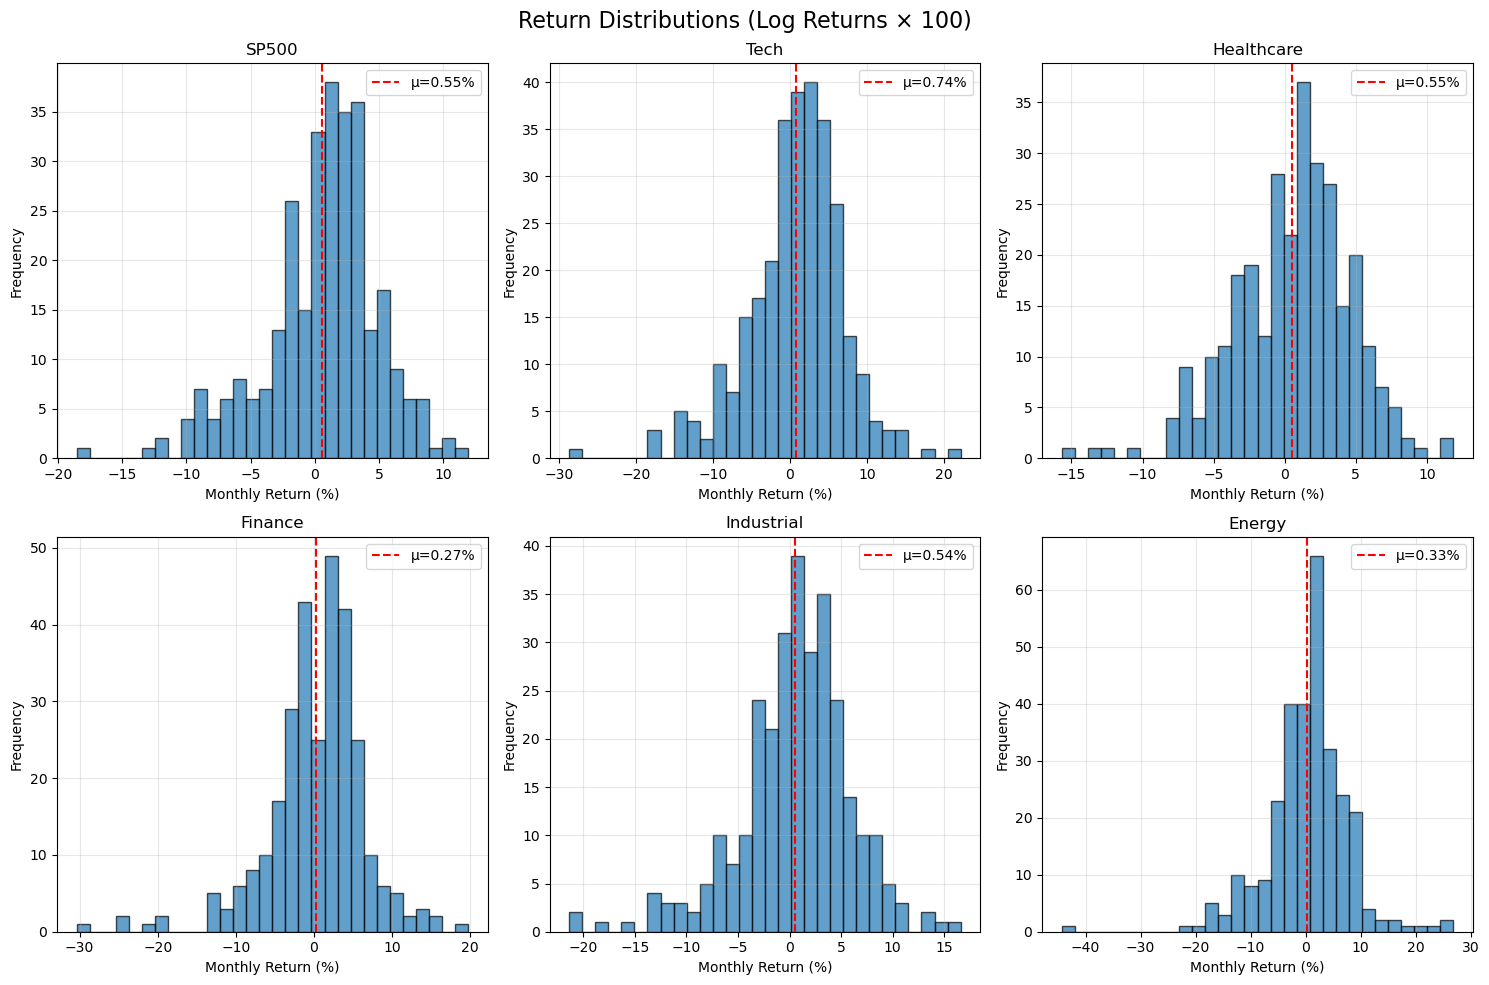

  Saved ../results/eda_after_preprocessing/01_distributions.png


In [8]:


return_cols = ['SP500_Return', 'Tech_Return', 'Healthcare_Return', 
               'Finance_Return', 'Industrial_Return', 'Energy_Return']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Return Distributions (Log Returns × 100)', fontsize=16)

for idx, col in enumerate(return_cols):
    ax = axes[idx // 3, idx % 3]
    
    # Histogram
    ax.hist(df[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(df[col].mean(), color='red', linestyle='--', 
               label=f'μ={df[col].mean():.2f}%')
    ax.set_title(col.replace('_Return', ''))
    ax.set_xlabel('Monthly Return (%)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
save("01_distributions", PLT_SAVE_DIR)



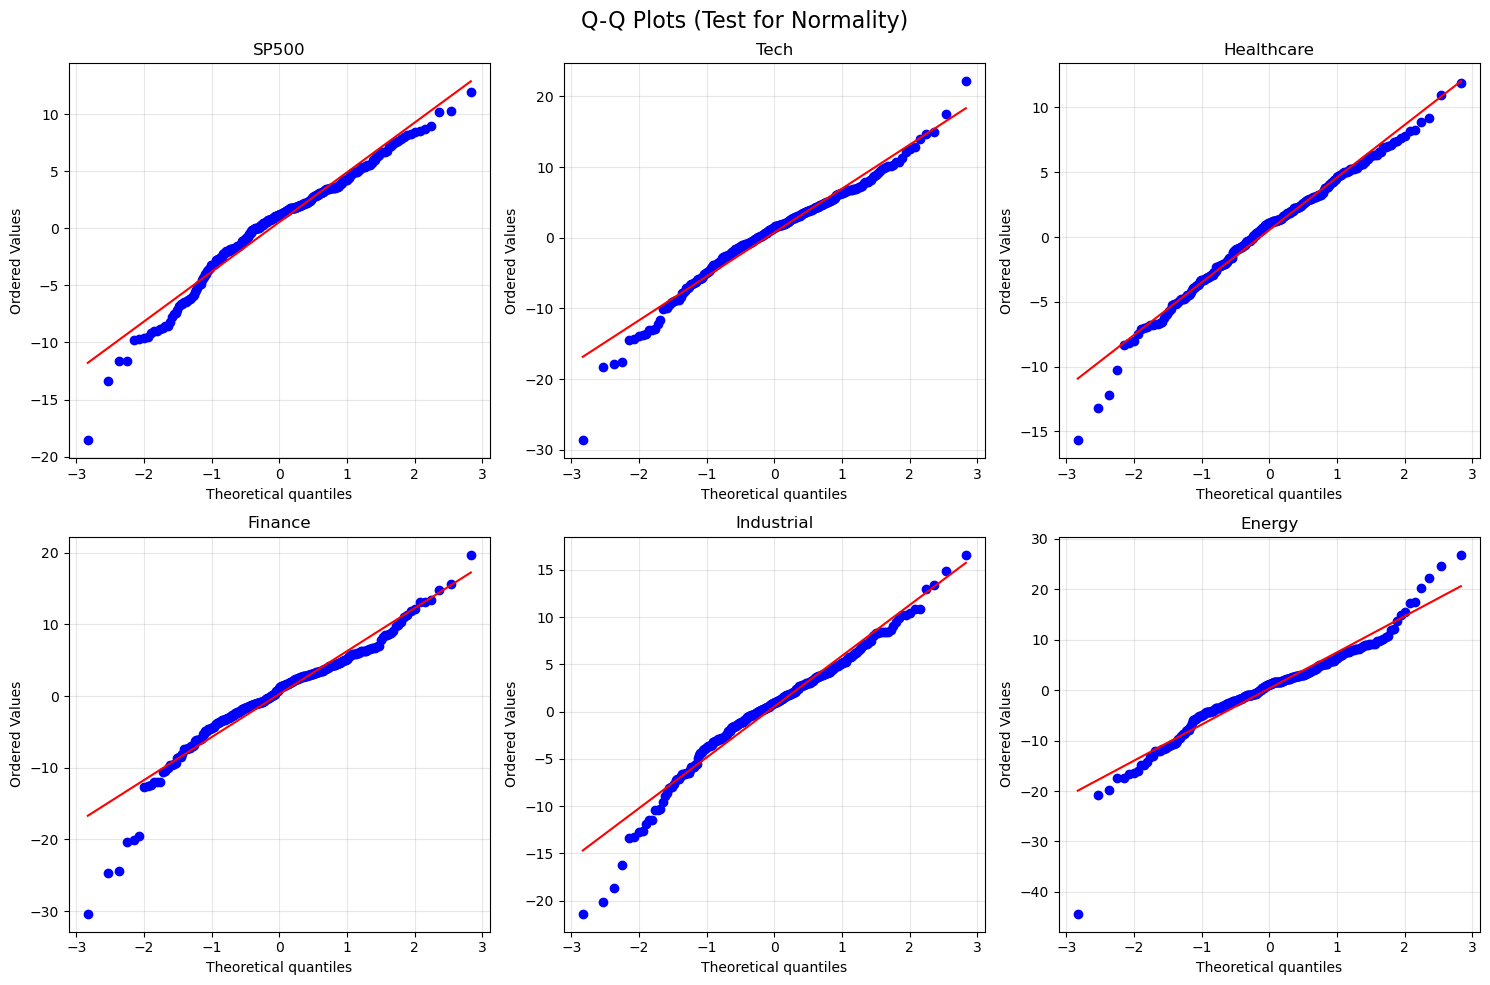

  Saved ../results/eda_after_preprocessing/02_qq_plots.png


In [9]:
# Q-Q plots (check normality)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Q-Q Plots (Test for Normality)', fontsize=16)

for idx, col in enumerate(return_cols):
    ax = axes[idx // 3, idx % 3]
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(col.replace('_Return', ''))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
save("02_qq_plots", PLT_SAVE_DIR)

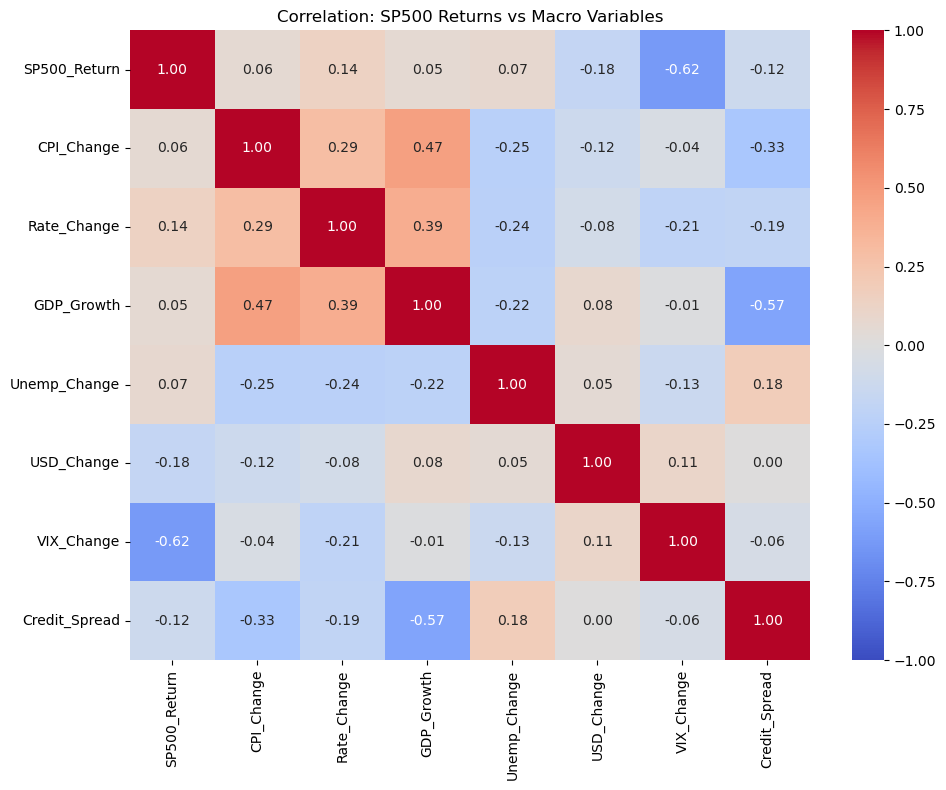

  Saved ../results/eda_after_preprocessing/03_correlation_heatmap.png


In [10]:
# Correlation between returns and macro variables
feature_cols = ['CPI_Change', 'Rate_Change', 'GDP_Growth', 
                'Unemp_Change', 'USD_Change', 'VIX_Change', 'Credit_Spread']

# For S&P 500
corr_data = df[['SP500_Return'] + feature_cols].dropna()
corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1)
plt.title('Correlation: SP500 Returns vs Macro Variables')
plt.tight_layout()
plt.show()
save("03_correlation_heatmap", PLT_SAVE_DIR)



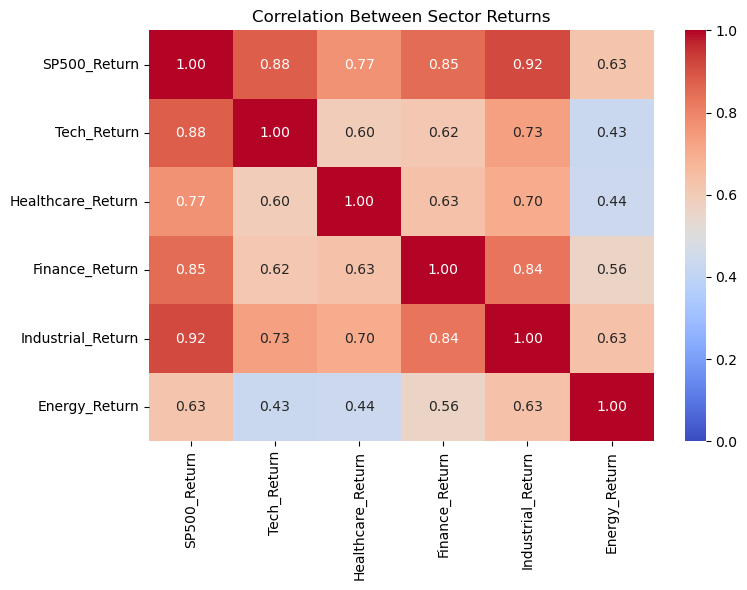

  Saved ../results/eda_after_preprocessing/04_sector_correlation.png


In [11]:
# Cross-sector correlation
sector_corr = df[return_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(sector_corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=0, vmax=1)
plt.title('Correlation Between Sector Returns')
plt.tight_layout()
plt.show()
save("04_sector_correlation", PLT_SAVE_DIR)

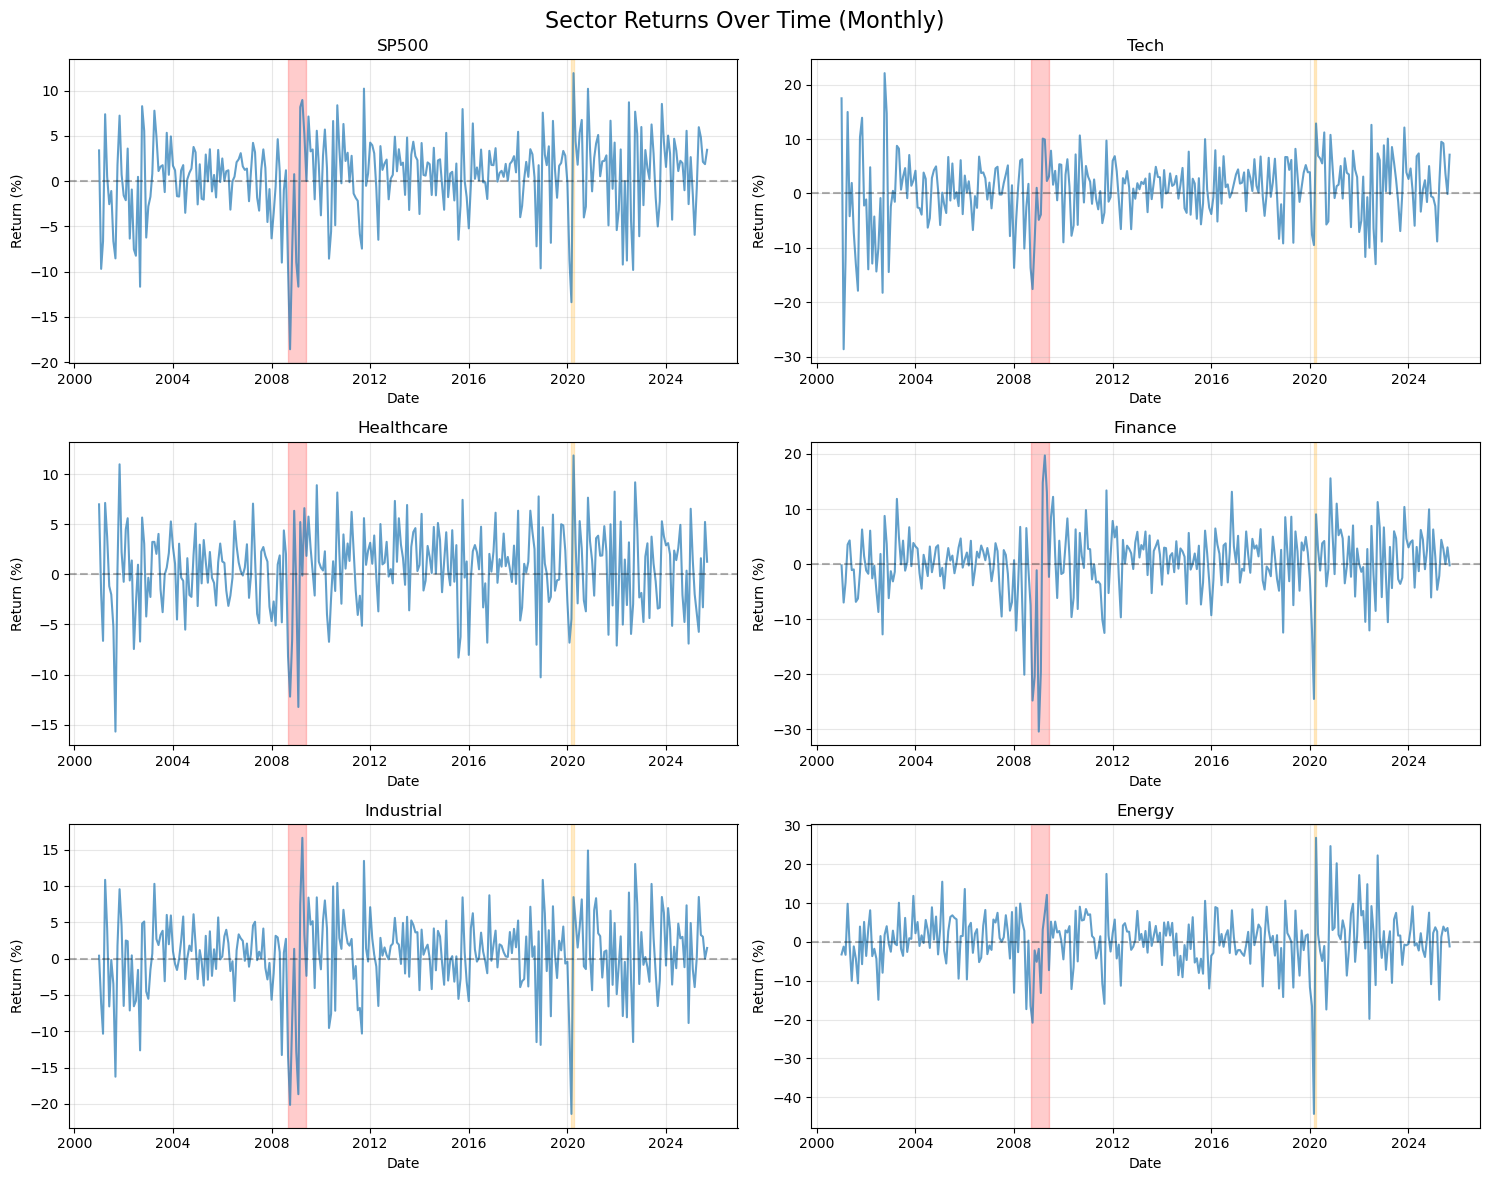

  Saved ../results/eda_after_preprocessing/05_returns_over_time.png


In [12]:
# Plot returns over time
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Sector Returns Over Time (Monthly)', fontsize=16)

for idx, col in enumerate(return_cols):
    ax = axes[idx // 2, idx % 2]
    ax.plot(df['Date'], df[col], alpha=0.7)
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax.set_title(col.replace('_Return', ''))
    ax.set_xlabel('Date')
    ax.set_ylabel('Return (%)')
    ax.grid(True, alpha=0.3)
    
    # Highlight crisis periods
    ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-01'), 
               alpha=0.2, color='red', label='2008 Crisis')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-04-01'), 
               alpha=0.2, color='orange', label='COVID-19')

plt.tight_layout()
plt.show()
save("05_returns_over_time", PLT_SAVE_DIR)

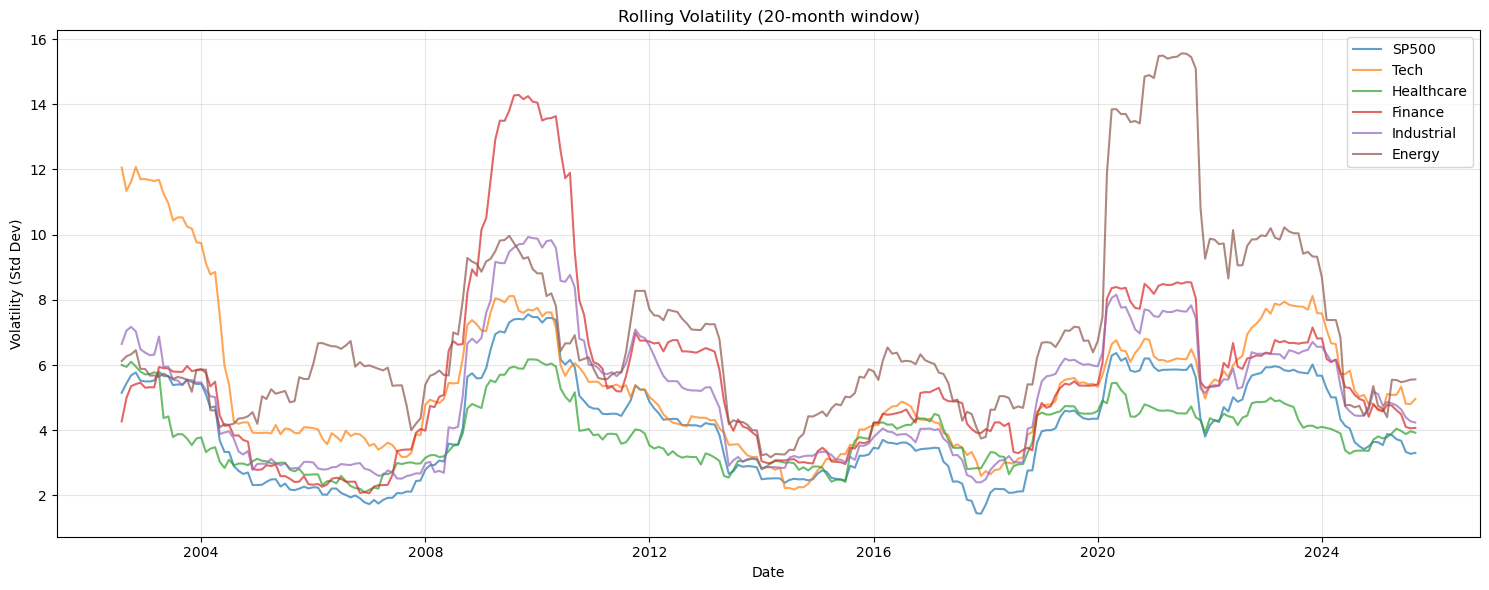

  Saved ../results/eda_after_preprocessing/06_rolling_volatility.png


In [13]:
# Rolling volatility (20-month window)
fig, ax = plt.subplots(figsize=(15, 6))

for col in return_cols:
    rolling_vol = df[col].rolling(window=20).std()
    ax.plot(df['Date'], rolling_vol, label=col.replace('_Return', ''), alpha=0.7)

ax.set_title('Rolling Volatility (20-month window)')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (Std Dev)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
save("06_rolling_volatility", PLT_SAVE_DIR)

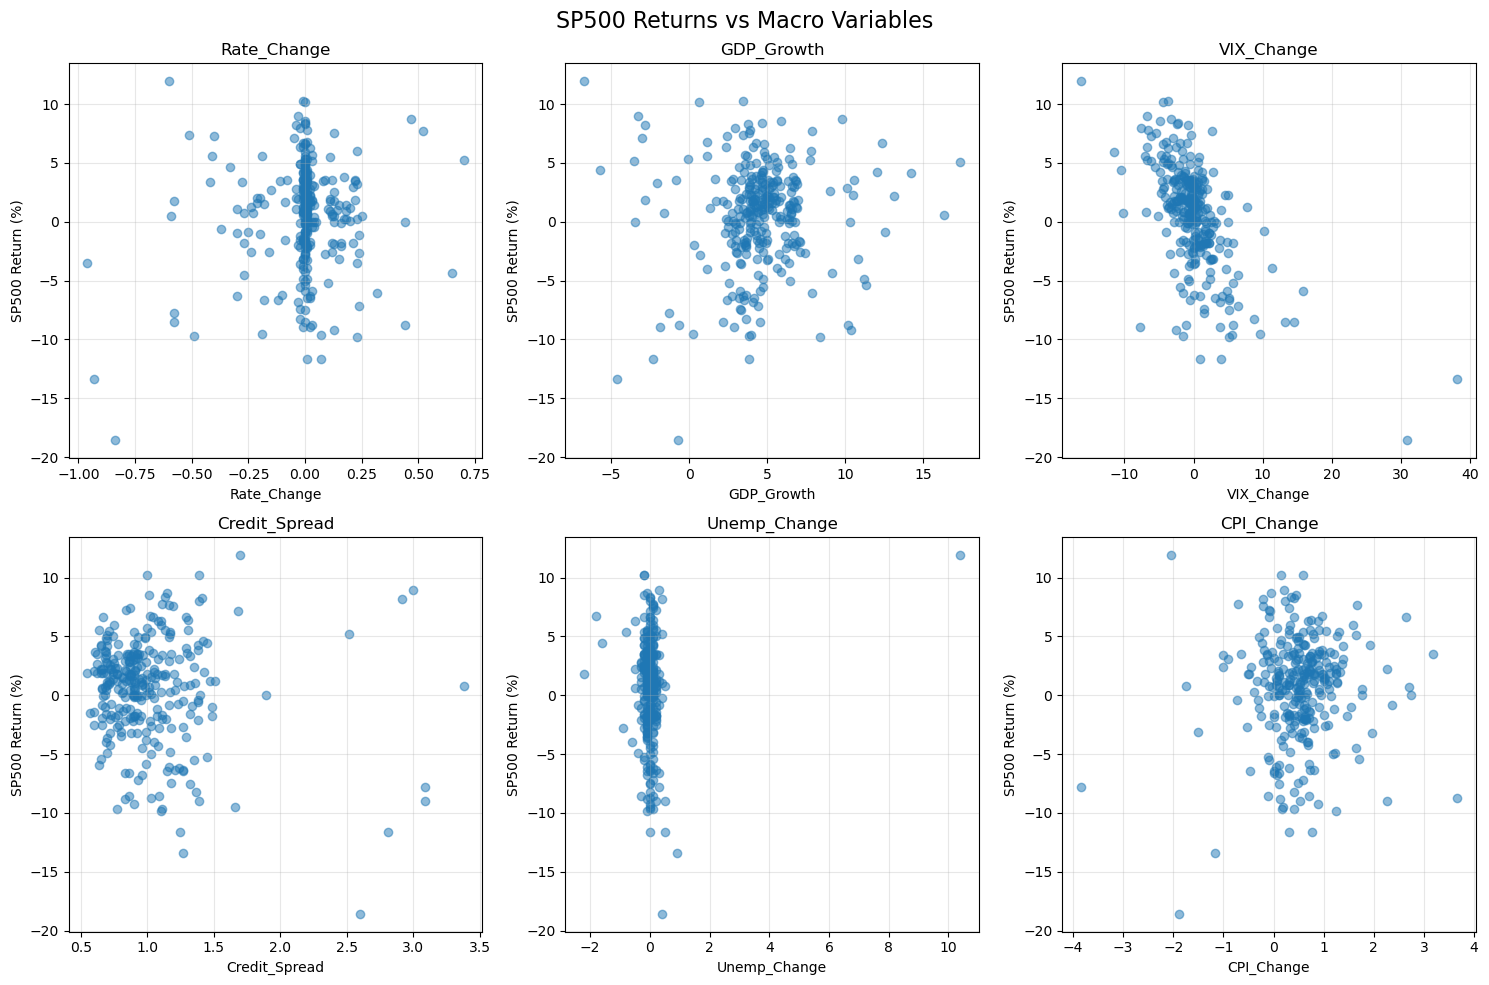

  Saved ../results/eda_after_preprocessing/07_scatter_returns_vs_macro.png


In [14]:
# Scatter plots: Returns vs key macro variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('SP500 Returns vs Macro Variables', fontsize=16)

macro_vars = ['Rate_Change', 'GDP_Growth', 'VIX_Change', 
              'Credit_Spread', 'Unemp_Change', 'CPI_Change']

for idx, var in enumerate(macro_vars):
    ax = axes[idx // 3, idx % 3]
    
    # Scatter plot
    ax.scatter(df[var], df['SP500_Return'], alpha=0.5)
    
    # Add trend line
    # from numpy.polynomial.polynomial import polyfit
    # mask = df[[var, 'SP500_Return']].notna().all(axis=1)
    # b, m = polyfit(df.loc[mask, var], df.loc[mask, 'SP500_Return'], 1)
    # ax.plot(df[var], m*df[var] + b, color='red', linestyle='--', alpha=0.7)
    
    ax.set_xlabel(var)
    ax.set_ylabel('SP500 Return (%)')
    ax.set_title(var)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
save("07_scatter_returns_vs_macro", PLT_SAVE_DIR)

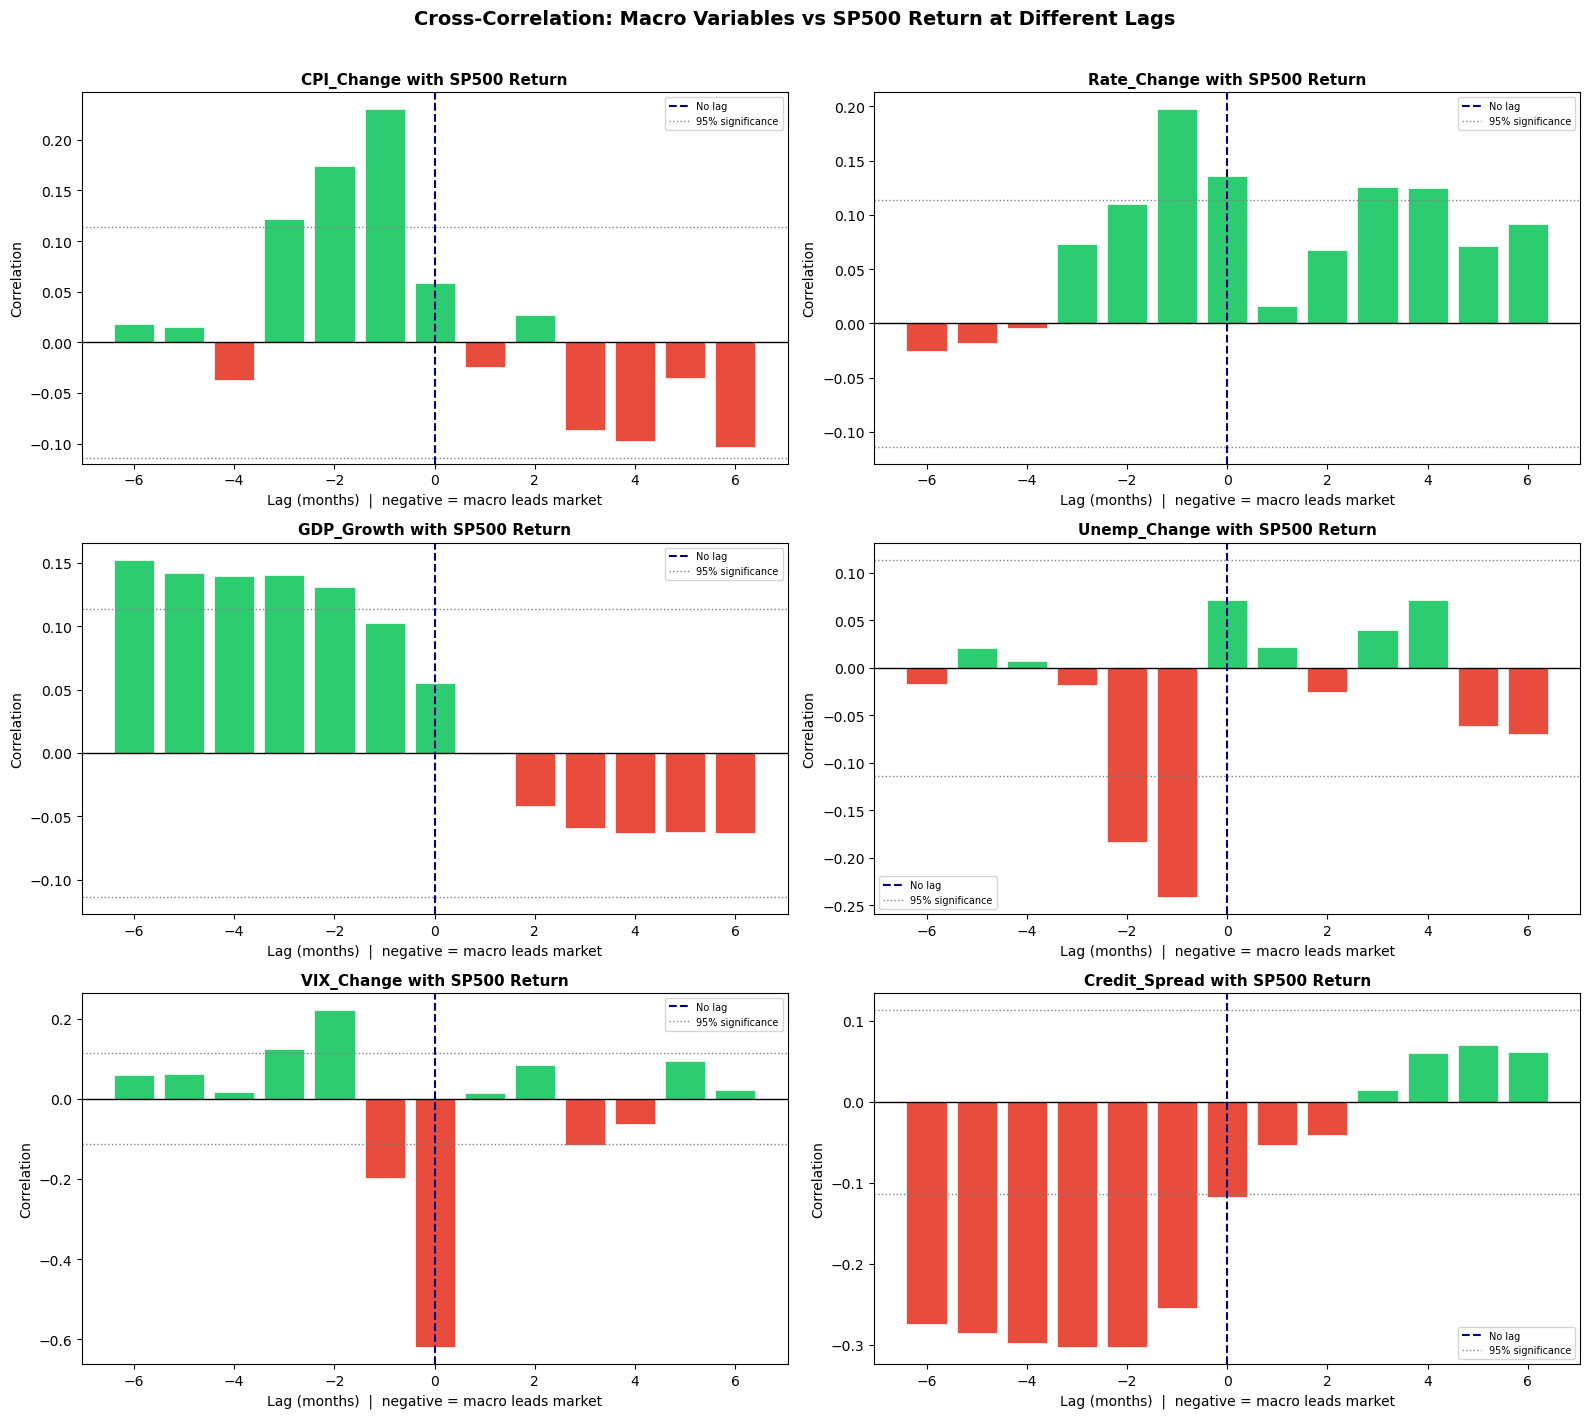

  Saved ../results/eda_after_preprocessing/08_cross_correlation_lags.png


In [15]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

macro_vars = ['CPI_Change', 'Rate_Change', 'GDP_Growth',
              'Unemp_Change', 'VIX_Change', 'Credit_Spread']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, var in enumerate(macro_vars):

    # Cross-correlation at each lag (-6 to 6 months)
    lags   = range(-6, 7)
    corrs  = [df['SP500_Return'].corr(df[var].shift(lag)) for lag in lags]

    axes[i].bar(lags, corrs,
                color=['#2ecc71' if c > 0 else '#e74c3c' for c in corrs],
                edgecolor='white', linewidth=0.5)

    axes[i].axhline(0,    color='black',  linewidth=1)
    axes[i].axvline(0,    color='navy',   linewidth=1.5, linestyle='--', label='No lag')

    # Significance bands (±1.96/√n)
    sig = 1.96 / np.sqrt(len(df))
    axes[i].axhline( sig, color='gray', linewidth=1, linestyle=':', label='95% significance')
    axes[i].axhline(-sig, color='gray', linewidth=1, linestyle=':')

    axes[i].set_title(f'{var} with SP500 Return', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Lag (months)  |  negative = macro leads market')
    axes[i].set_ylabel('Correlation')
    axes[i].legend(fontsize=7)

fig.suptitle('Cross-Correlation: Macro Variables vs SP500 Return at Different Lags',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
save("08_cross_correlation_lags", PLT_SAVE_DIR)

In [16]:
summary = df[return_cols].describe().T
summary['Skewness'] = df[return_cols].skew()
summary['Kurtosis'] = df[return_cols].kurtosis()

print("Summary Statistics")
print("="*80)
print(summary.round(2))
print("="*80)

Summary Statistics
                   count  mean   std    min   25%   50%   75%    max  \
SP500_Return       297.0  0.55  4.41 -18.56 -1.77  1.20  3.35  11.94   
Tech_Return        297.0  0.74  6.29 -28.64 -2.39  1.42  4.60  22.13   
Healthcare_Return  297.0  0.55  4.06 -15.68 -2.06  1.06  3.08  11.86   
Finance_Return     297.0  0.27  6.19 -30.38 -2.57  1.17  3.78  19.72   
Industrial_Return  297.0  0.54  5.45 -21.38 -2.05  0.94  3.80  16.61   
Energy_Return      297.0  0.33  7.37 -44.33 -3.16  1.19  4.11  26.82   

                   Skewness  Kurtosis  
SP500_Return          -0.74      1.28  
Tech_Return           -0.63      2.05  
Healthcare_Return     -0.48      0.87  
Finance_Return        -1.05      3.92  
Industrial_Return     -0.70      1.94  
Energy_Return         -0.70      5.22  
